## Catastro Minero de Salta

### Notebook 01: EDA y Limpieza de Datos

### Fecha: Junio 2026

### Proyecto: Análisis del catastro minero oficial de la provincia de Salta, Argentina

Fuente: Geoportal oficial de Salta

###Autora: Camila Mopty
#### Fecha: 2026
--------------------------------------------

In [1]:
#@title
#LIBRERÍAS

import subprocess
import os
import warnings
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime

import geopandas as gpd
from shapely.validation import make_valid

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import folium
from io import StringIO

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
import importlib
for lib in ['numpy','pandas','geopandas','shapely','pyproj','fiona',
           'folium','plotly','mapclassify','sklearn']:
    try:
        print(f"{lib:12s} {importlib.import_module(lib).__version__}")
    except Exception as e:
        print(f"{lib:12s} no instalada ({e})")

numpy        2.1.3
pandas       2.2.3
geopandas    1.1.4
shapely      2.1.2
pyproj       3.7.2
fiona        no instalada (No module named 'fiona')
folium       0.20.0
plotly       5.24.1
mapclassify  2.10.0
sklearn      1.6.1


In [3]:
!pip freeze | grep -Ei "^(numpy|pandas|geopandas|shapely|pyproj|fiona|folium|plotly|mapclassify|scikit-learn)==" > requirements.txt

In [4]:
import os, random
import numpy as np

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [5]:
#@title
# Clonación del repositorio

repo_url = "https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git"
repo_name = "catastro-minero-salta-mining-registry-salta"

if not os.path.exists(repo_name):
    subprocess.run(["git", "clone", repo_url], check=True)

else:
    print("El repositorio ya existe en el entorno.")

# Rutas
data_raw = f"https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git/data/raw/"
shapefile = f"https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git/data/raw/junio_2026/poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp"

In [6]:
#@title
import subprocess, sys

packages = [
    'geopandas',
    'pyproj',
    'folium',
    'missingno',
    'mapclassify',
    'fiona'
]

print('✓ Todas las dependencias instaladas correctamente.')

✓ Todas las dependencias instaladas correctamente.


In [7]:
#@title
# Leer el shapefile
catastro_minero = gpd.read_file("catastro-minero-salta-mining-registry-salta/data/raw/junio_2026/poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp",
encoding='latin-1'
)

# Convertir a WGS84 si no está ya
cmin = catastro_minero.to_crs(epsg=4326)

mask_invalidas = ~cmin.geometry.is_valid
cmin.loc[mask_invalidas, 'geometry'] = cmin.loc[mask_invalidas, 'geometry'].apply(make_valid)


## 3. EDA- Exploración inicial
*Dataset catastro minero completo*

In [8]:
#@title
# Tabla info

column_info = pd.DataFrame({
    'Column': cmin.columns,
    'Non-Null Count': cmin.count().values,
    'Dtype': cmin.dtypes.values
})

display(column_info)


,Column,Non-Null Count,Dtype
0,fid,3953,int32
1,tipo,3953,object
2,expediente,3951,object
3,nombre,3866,object
4,mineral,3350,object
5,concesiona,3576,object
6,estado,3953,object
7,resolucion,96,object
8,fecha_inic,3778,datetime64[ms]
9,departamen,3952,object


Valores de tipo y de estado

In [9]:
#@title
# Valores de tipo y de estado
print(f'Tipo: {cmin['tipo'].unique()}')
print(f'estado: {cmin['estado'].unique()}')


Tipo: ['Convenio' 'Mina' 'Manifestacion' 'Servidumbre' 'Cateo' 'Cantera'
 'Zona de Investigación Geológica Minera' 'Grupo Minero']
estado: ['Vigente' 'Vacante' 'Anulación de registro sin publicar (REMSa)'
 'Anulación de registro sin publicar']


El Código de Minería de la República Argentina, aprobado por Ley N° 1919 define:
###Tipo
- Cateo: Es un derecho temporal exclusivo para realizar trabajos de búsqueda y  prospección de minerales en un área determinada con excavaciones de prueba.
- Manifestación: Es el acto formal y técnico donde el cateador notifica el hallazgo de un yacimiento nuevo. Genera prioridad legal sobre el terreno para transformar el cateo en una concesión de mina.
- Mina: Es la propiedad minera propiamente dicha, concedida por el Estado de manera perpetua. Explotación de sustancias de primera y segunda categoría.
- Cantera:Explotación de sustancias de Tercera Categoría (minerales industriales, rocas de aplicación, arenas, piedras de construcción).
- Grupo Minero: Es la unificación catastral y operativa de dos o más pertenencias de minas contiguas para ser explotadas bajo un único plan de trabajos unificado.
- Servidumbre: Derecho de ocupación o uso que la ley le concede al minero sobre los terrenos superficiales para caminos de acceso, acueductos, tendidos eléctricos o campamentos, con previa indemnización al propietario.
- Zona de Investigación Geológica Minera: Áreas reservadas temporalmente por el Estado (o corporaciones estatales delegadas) para que organismos oficiales de investigación geológica realicen prospecciones a gran escala. Durante la vigencia de esta zona, queda suspendida la admisión de peticiones de cateos o manifestaciones de descubrimiento por parte de particulares.

###Estado
- Vigente: El derecho minero se encuentra plenamente activo y válido.
- Vacante: El derecho minero previo ha caducado, ha sido revocado o el plazo del cateo expiró y el área ya ha sido liberada formalmente mediante publicación en el Boletín Oficial.
- Anulación de registro sin publicar: La Autoridad Minera ya ha dictado la resolución  de caducidad o rechazo ese expediente pero aún no se ha publicado en el Boletín Oficial.
- Anulación de registro sin publicar (REMSa): una mina cae en caducidad y el Juzgado de Minas dicta la anulación del registro, pero el área no se libera para el público general sino que se transfiere preferencialmente a la empresa estatal REMSa S.A. para que esta evalúe su potencial y la someta a licitación o concurso público de proyectos.

In [10]:
#@title
# Cantidad y porcentaje de nulos por columna

nulos = pd.DataFrame({
    'nulos/vacios': cmin.isnull().sum(),
    'porcentaje':  (cmin.isnull().sum() / len(cmin) * 100).round(1),
}).sort_values('porcentaje', ascending=False)

print(nulos)

            nulos/vacios  porcentaje
resolucion          3857        97.6
mineral              603        15.3
lugar                555        14.0
concesiona           377         9.5
fecha_inic           175         4.4
nombre                87         2.2
municipio             49         1.2
expediente             2         0.1
estado                 0         0.0
fid                    0         0.0
tipo                   0         0.0
departamen             1         0.0
area                   0         0.0
coordenada             0         0.0
geometry               0         0.0


In [11]:
#@title
# Transformación: campo 'area' a float
# Paso 1: eliminar 'ha' del final
# Paso 2: reemplazar ',' por '.'
# Paso 3: convertir a float

cmin['area_ha'] = (
    cmin['area']
    .str.replace(' ha', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
cmin['fecha_inic'] = pd.to_datetime(cmin['fecha_inic'], errors='coerce', dayfirst=True)



###Clasificación
*Dataset con datos en el atributo tipo de mineral*

In [12]:
#@title
# Creación de subconjunto para análisis de minerales
# Criterio: excluir registros donde 'mineral' es NaN o string vacío


cmin_completo = cmin[
    cmin['mineral'].notna() &
    (cmin['mineral'].str.strip() != '')
].copy()

# Verificación
print(f"Dataset completo:           {len(cmin):,} registros")
print(f"Dataset con mineral:        {len(cmin_completo):,} registros")
print(f"Registros excluidos:        {len(cmin) - len(cmin_completo):,}")


Dataset completo:           3,953 registros
Dataset con mineral:        3,350 registros
Registros excluidos:        603


In [13]:
#@title
# Cantidad y porcentaje de nulos por columna set de datos con minerales

nulos = pd.DataFrame({
    'nulos/vacios': cmin_completo.isnull().sum(),
    'porcentaje':  (cmin_completo.isnull().sum() / len(cmin_completo) * 100).round(1),
}).sort_values('porcentaje', ascending=False)

print(nulos)

            nulos/vacios  porcentaje
resolucion          3260        97.3
concesiona           279         8.3
lugar                263         7.9
fecha_inic           135         4.0
nombre                72         2.1
expediente             2         0.1
fid                    0         0.0
tipo                   0         0.0
estado                 0         0.0
mineral                0         0.0
departamen             0         0.0
municipio              1         0.0
area                   0         0.0
coordenada             0         0.0
geometry               0         0.0
area_ha                0         0.0


## Clasificación de pedimetos con minerales críticos

In [14]:
#@title
# Clasificación one-hot
# Detecta presencia de Li, Cu , Au en el campo mineral como palabras completas delimitadas por ',' o espacios o aisladas

mineral_col = cmin_completo['mineral'].fillna('')

CRITICOS = {'LI', 'CU', 'AU'}

def es_critico(valor):
    if pd.isna(valor):
        return False
    tokens = {t.strip().upper() for t in str(valor).split(',')}
    return bool(tokens & CRITICOS)

cmin_completo['minerales_criticos'] = cmin_completo['mineral'].apply(es_critico)

In [15]:
#@title
# Filtrado y creación de conjunto de datos con minerales criticos
# Criterio: Seleccionar pedimentos con minerales críticos (Li, Cu, y/o Au)
cmin_critico = cmin_completo[
    cmin_completo['minerales_criticos'] == True
].copy()

# Verificación
print(f"Dataset completo:           {len(cmin):,} registros")
print(f"Dataset con mineral:        {len(cmin_completo):,} registros")
print(f"Dataset con minerales criticos: {len(cmin_critico):,} registros")
print(f"Registros excluidos:        {len(cmin_completo) - len(cmin_critico):,}")


Dataset completo:           3,953 registros
Dataset con mineral:        3,350 registros
Dataset con minerales criticos: 2,047 registros
Registros excluidos:        1,303


Valores de tipo y estado

In [16]:
#@title
# Valores de tipo y de estado

print(f'Tipo: {cmin_critico['tipo'].unique()}')
print(f'estado: {cmin_critico['estado'].unique()}')

Tipo: ['Mina' 'Manifestacion']
estado: ['Vacante' 'Vigente' 'Anulación de registro sin publicar (REMSa)'
 'Anulación de registro sin publicar']


# Tablas resumen

In [17]:
#@title
def split_by_critical(df):
    return df[df['minerales_criticos'] == True], df[df['minerales_criticos'] == False]

crit, non_crit = split_by_critical(cmin_completo)

# Tablas resumen
def build_general_summary(crit, non_crit, total):
    return pd.DataFrame({
        'Indicador': ['Total pedimentos', 'Superficie total (ha)'],
        'Minerales críticos': [
            len(crit),
            round(crit['area_ha'].sum(), 2)
        ],
        'Sin minerales críticos': [
            len(non_crit),
            round(non_crit['area_ha'].sum(), 2)
        ],
        'Total': [
            len(total),
            round(total['area_ha'].sum(), 2)
        ]
    })

summary_general = build_general_summary(crit, non_crit, cmin_completo)

# por tipo
def build_breakdown(crit, non_crit, total, col):
    """
    Builds a cross-tabulation of `col` values for each mineral category.
    Uses outer join to preserve all values even if absent in one category.
    """
    c = crit[col].value_counts().rename('Minerales críticos')
    n = non_crit[col].value_counts().rename('Sin minerales críticos')
    t = total[col].value_counts().rename('Total')

    df = pd.concat([c, n, t], axis=1).fillna(0).astype(int)
    df.index.name = col.capitalize()
    return df.reset_index()

summary_tipo   = build_breakdown(crit, non_crit, cmin_completo, 'tipo')
summary_estado = build_breakdown(crit, non_crit, cmin_completo, 'estado')


def style_table(df, title):
    """Applies consistent styling: header color, alternating rows."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    styled = (
        df.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th',
             'props': [('background-color', '#4A4A4A'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center')]},
            {'selector': 'tr:nth-child(odd)',
             'props': [('background-color', '#E0E0E0'),
                       ('color', 'black')]},
            {'selector': 'tr:nth-child(even)',
             'props': [('background-color', '#CCCCCC'),
                       ('color', 'black')]}
        ])
        .format(precision=2)
        .hide(axis='index')
    )
    display(styled)

style_table(summary_general, "1 · Totales generales")
style_table(summary_tipo,    "2 · Distribución por tipo")
style_table(summary_estado,  "3 · Distribución por estado")


  1 · Totales generales


Indicador,Minerales críticos,Sin minerales críticos,Total
Total pedimentos,2047.00,1303.00,3350.00
Superficie total (ha),2851604.14,549718.64,3401322.77



  2 · Distribución por tipo


Tipo,Minerales críticos,Sin minerales críticos,Total
Mina,1208,446,1654
Manifestacion,839,198,1037
Cantera,0,491,491
Convenio,0,168,168



  3 · Distribución por estado


Estado,Minerales críticos,Sin minerales críticos,Total
Vigente,1946,1238,3184
Vacante,85,55,140
Anulación de registro sin publicar (REMSa),8,5,13
Anulación de registro sin publicar,8,5,13


## 5. Gráficos

**5.1. Cantidad total de pedimentos según departamentos - gráfico de barras**

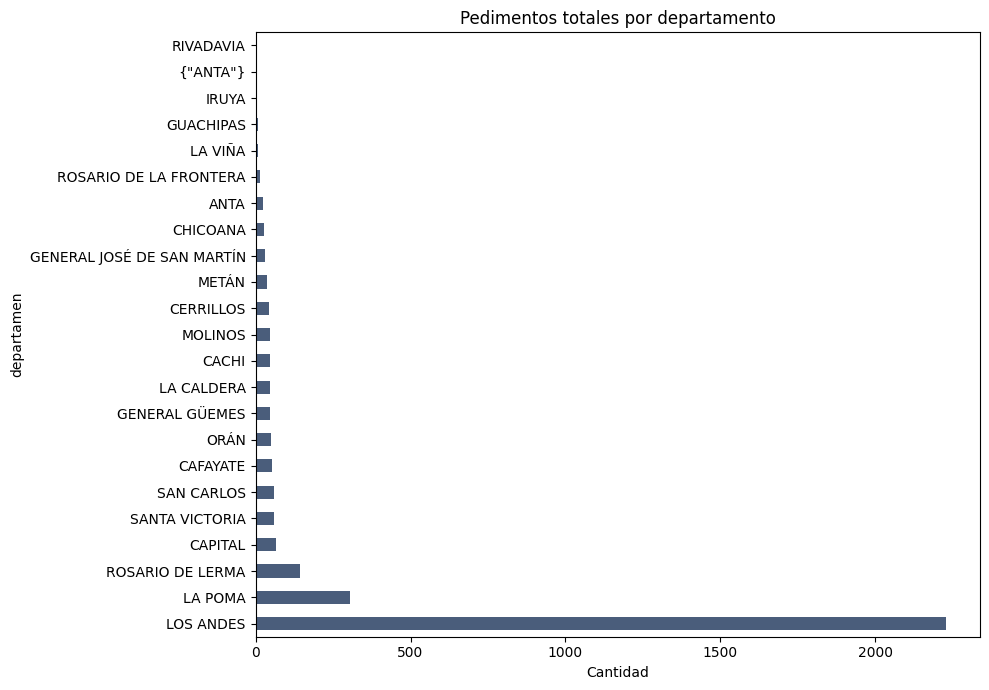

In [18]:
#@title
# Grafico 1 Distribución por departamentos grafico de barras
cmin_completo['departamen'].value_counts().plot(
    kind='barh', figsize=(10, 7), color='#4a5d7b'
)
plt.title('Pedimentos totales por departamento')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

**5.2. Cantidad total de pedimentos según departamentos - gráfico de tortas**

In [19]:
#@title
# Grafico 2: Pedimentos por departamentos en gráfico de tortas
exp_depto = (
    cmin_completo['departamen']
    .value_counts()
)

# Agrupar departamentos menores en 'Otros'
threshold = exp_depto.sum() * 0.03
otros = exp_depto[exp_depto < threshold].sum()
exp_depto_plot = exp_depto[exp_depto >= threshold].copy()
if otros > 0:
    exp_depto_plot['Otros'] = otros

fig = go.Figure(go.Pie(
    labels=exp_depto_plot.index,
    values=exp_depto_plot.values,
    hole=0,
    marker=dict(colors=['#4a5d7b', '#262134', '#899eac', '#3e4a38',
                         '#4a543c', '#8E44AD', '#C0392B']),
    textinfo='percent+label',
    textfont=dict(size=11),
))

fig.update_layout(
    title=dict(
        text='Pedimentos totales por departamento',
        font=dict(size=15, color='#2C3E50'),
        x=0.5
    ),
    legend=dict(orientation='v', x=1.05),

    margin=dict(t=60, b=20, l=20, r=150),
    width=600, height=420
)
fig.show()
fig.write_html('grafico de tortas departamento')

**5.3. Cantidad total de pedimentos con y sin minerales críticos - Gráfico de barras**

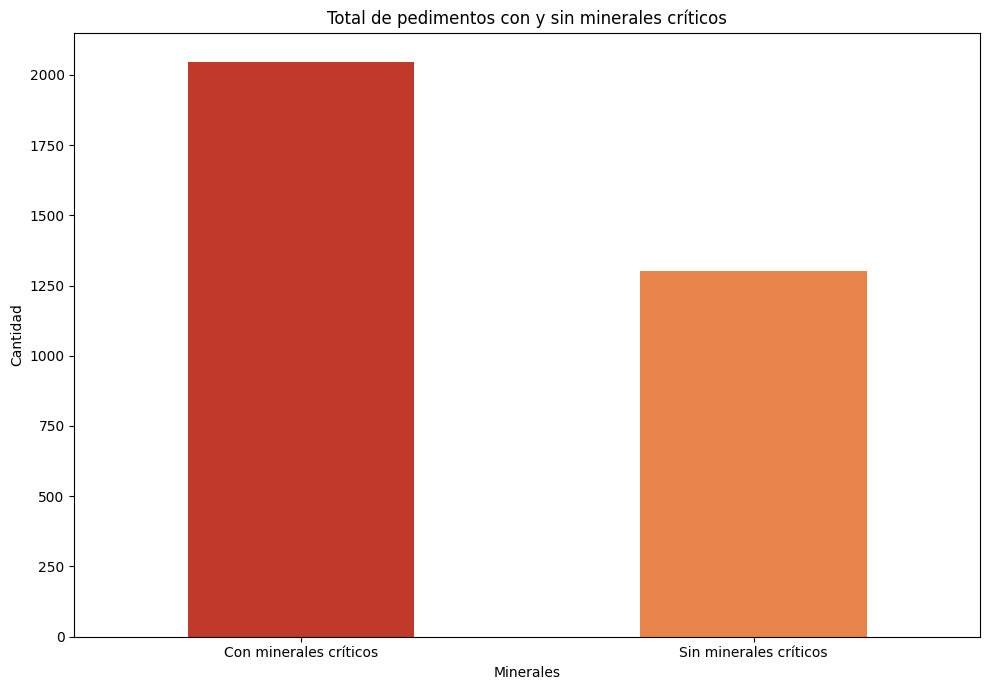

In [20]:
#@title
# Grafico 3: Pedimentos por departamentos en gráfico de tortas
counts = cmin_completo['minerales_criticos'].value_counts()
colors = {True: '#C0392B', False: '#E8834A'}
labels = {True: 'Con minerales críticos', False: 'Sin minerales críticos'}

plot_colors = [colors[idx] for idx in counts.index]
plot_labels = [labels[idx] for idx in counts.index]

counts.plot(
    kind='bar', figsize=(10, 7), color=plot_colors
)
plt.title('Total de pedimentos con y sin minerales críticos')
plt.xlabel('Minerales')
plt.ylabel('Cantidad')
plt.xticks(ticks=[0, 1], labels=plot_labels, rotation=0)
plt.tight_layout()
plt.show()

**5.4. Pedimentos con y sin minerales críticos según área por departamento - gráfico de barras apiladas**

In [21]:
#@title
# Gráfico 4: Cantidad de pedimentos con y sin mínerales críticos (Li, Cu, Au) por departamento

sup_depto = (
    cmin_completo
    .groupby(['departamen', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index()
)

# Solo top 8 departamentos por superficie total
top_deptos = (
    cmin_completo.groupby('departamen')['area_ha']
    .sum()
    .nlargest(8)
    .index.tolist()
)

sup_depto_top = sup_depto[sup_depto['departamen'].isin(top_deptos)]

# Separar SI y NO
sup_si = sup_depto_top[sup_depto_top['minerales_criticos'] == True].set_index('departamen')['area_ha']
sup_no = sup_depto_top[sup_depto_top['minerales_criticos'] == False].set_index('departamen')['area_ha']

# Ordenar por superficie total descendente
orden = (sup_si.fillna(0) + sup_no.fillna(0)).sort_values(ascending=True).index

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=orden,
    x=[sup_si.get(d, 0) for d in orden],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(orden),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=orden,
    x=[sup_no.get(d, 0) for d in orden],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(orden),
    textposition='inside'
))

# Etiquetas
for depto in orden:
    val_si = sup_si.get(depto, 0)
    val_no = sup_no.get(depto, 0)
    total  = val_si + val_no

    label_si = f"{val_si/1e6:.2f}M ha" if val_si >= 1e6 else f"{val_si:,.0f} ha".replace(',', '.')
    label_no = f"{val_no/1e6:.2f}M ha" if val_no >= 1e6 else f"{val_no:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=depto,
        text=f"<b>{label_si}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=depto,
        text=f"<b>{label_no}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=-1
    )

fig.update_layout(
    barmode='stack',
    separators='.',
    title=dict(
        text='Superficie (ha) total con y sin minerales críticos por departamento',
        font=dict(size=15, color='#2C3E50'),
        x=0.15
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(title='', showgrid=False),
    legend=dict(orientation='h', y=-0.15),
    margin=dict(t=60, b=80, l=180, r=200),
    width=950, height=500,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()
fig.write_html('grafico de barras superficie pedimentos con y sin minerales criticos por año ')

**5.5. Cantidad de Pedimentos con y sin mínerales críticos por año de iniciación (2009-2025) - Gráfico de barras apiladas**

In [22]:
#@title
# Gráfico 5: Cantidad de pedimentos por año de iniciación a partir de 2009

exp_anio = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=lambda df: df['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerale críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Cantidad de pedimentos por año con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('grafico de barras cantidad de pedimentos con y sin minerales criticos por año')

<Figure size 640x480 with 0 Axes>

**5.6. Superficie de Pedimentos con y sin mínerales críticos por año de iniciación (2009-2025) - Gráfico de barras apiladas**

In [23]:
#@title
# Gráfico 6: Superficie (ha) de pedimentos por año de iniciación a partir de 2009

exp_anio = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=lambda df: df['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index(name='area_total_ha')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['area_total_ha']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['area_total_ha']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M ha" if val_con >= 1e6 else f"{val_con:,.0f} ha".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M ha" if val_sin >= 1e6 else f"{val_sin:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Superficie (ha) de pedimentos por año con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Superficie (ha)',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('grafico_barras_superficie_por_anio_con_sin_minerales_criticos.html')

<Figure size 640x480 with 0 Axes>

**5.7. Cantidad de Pedimentos por tipo por año de iniciación (2009-2025) - Gráfico de barras apiladas**

In [24]:
cmin_completo.tipo.unique()

array(['Mina', 'Manifestacion', 'Convenio', 'Cantera'], dtype=object)

In [25]:
#@title
# Gráfico 7: Pedimentos según tipo por año (2009-2025)

# Filtrar datos por años y tipos específicos
selected_types = ['Mina', 'Manifestacion', 'Cantera', 'Convenio']

exp_anio_tipo = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=lambda df: df['fecha_inic'].dt.year)
    .query('2009 <= anio <= 2025') # Filter for years 2009 to 2025
    .groupby(['anio', 'tipo'])
    .size()
    .reset_index(name='cantidad')
)


exp_anio_tipo = exp_anio_tipo[exp_anio_tipo['tipo'].isin(selected_types)]
años = sorted(exp_anio_tipo['anio'].unique(), reverse=True)
tipos = sorted(exp_anio_tipo['tipo'].unique())

fig = go.Figure()

#Colores
colors_map = {
    'Mina': '#C0392B',          # Dark Red
    'Manifestacion': '#E8834A', # Orange
    'Cantera': '#3498DB',       # Blue
    'Convenio': '#27AE60'       # Green
}

for tipo_val in tipos:
    df_tipo = exp_anio_tipo[exp_anio_tipo['tipo'] == tipo_val].set_index('anio')['cantidad']
    fig.add_trace(go.Bar(
        name=tipo_val,
        y=años,
        x=[df_tipo.get(a, 0) for a in años],
        orientation='h',
        marker_color=colors_map.get(tipo_val, '#7F8C8D') # Default to grey if type not in map
    ))

cumulative_x = {a: 0 for a in años}

for tipo_val in tipos:
    df_tipo = exp_anio_tipo[exp_anio_tipo['tipo'] == tipo_val].set_index('anio')['cantidad']
    for anio_val in años:
        cantidad = df_tipo.get(anio_val, 0)
        if cantidad > 0:
            x_center = cumulative_x[anio_val] + cantidad / 2
            text_color = 'white' if tipo_val in ['Mina', 'Manifestacion', 'Convenio'] else 'black' # Adjusted for better contrast
            fig.add_annotation(
                x=x_center,
                y=anio_val,
                text=str(cantidad),
                showarrow=False,
                xanchor='center',
                yanchor='middle',
                font=dict(size=10, color=text_color)
            )
            cumulative_x[anio_val] += cantidad

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Pedimentos por año (2009-2025) según tipo de pedimento',
        font=dict(size=15, color='#2C3E50'),
        x=0.05
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12, x=0, xanchor='left'),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('grafico_barras_pedimentos_por_tipo_anio_2009_2025.html')

<Figure size 640x480 with 0 Axes>

**5.8. Cantidad de Pedimentos tipo Mina por año con y sin minerales críticos**

In [26]:
#@title
#Set de datos de pedimentos tipo 'Mina'

cmina = cmin_completo[cmin_completo['tipo'] == 'Mina']

In [27]:
#@title
# Gráfico 8: Cantidad de pedimentos tipo Mina por año con y sin minerales criticos

exp_anio = (
    cmina[cmina['fecha_inic'].notna()]
    .assign(anio=lambda df: df['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales criticos',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Cantidad de pedimentos tipo Mina con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('grafico de barras cantidad de minas por año')

<Figure size 640x480 with 0 Axes>

**5.9. Superficie de Pedimentos tipo Mina con y sin minerales criticos por año**

In [28]:
#@title
# Gráfico 9: Superficie (ha) de pedimentos tipo Mina por año con y sin minerales críticos

exp_anio = (
    cmina[cmina['fecha_inic'].notna()]
    .assign(anio=lambda df: df['fecha_inic'].dt.year)
    .query('anio >= 2009') # Filter for years 2009 to 2025
    .groupby(['anio', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index(name='area_total_ha')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['area_total_ha']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['area_total_ha']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M ha" if val_con >= 1e6 else f"{val_con:,.0f} ha".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M ha" if val_sin >= 1e6 else f"{val_sin:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Superficie (ha) de pedimentos tipo Mina con y sin minerales críticos por año',
        font=dict(size=15, color='#2C3E50'),
        x=0.05
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('superficie tipo Mina con y son minerales criticos')

<Figure size 640x480 with 0 Axes>

**5.10. Cantidad de Pedimentos tipo Manifestación por año con y sin minerales críticos**

In [29]:
#@title
#Set de datos de pedimentos tipo 'Manifestación'

cmanif = cmin_completo[cmin_completo['tipo'] == 'Manifestacion']

In [30]:
#@title
# Gráfico 10: Cantidad de pedimentos tipo Manifestación por año con y sin minerales criticos

exp_anio = (
    cmanif[cmanif['fecha_inic'].notna()] # Corrected to use cmanif's fecha_inic
    .assign(anio=lambda df: df['fecha_inic'].dt.year) # Corrected to use cmanif's fecha_inic
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales criticos',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Cantidad de pedimentos tipo Manifestación con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('Cantidad de pedimentos tipo Manifestación con y sin min criticos año')

<Figure size 640x480 with 0 Axes>

**5.11. Superficie de Pedimentos tipo Manifestacion por año**

In [31]:
#@title
# Gráfico 11: Superficie (ha) de pedimentos tipo Manifestacion por año

exp_anio = (
    cmanif[cmanif['fecha_inic'].notna()]
    .assign(anio=lambda df: df['fecha_inic'].dt.year)
    .query('anio >= 2009') # Filter for years 2009 to 2025
    .groupby(['anio', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index(name='area_total_ha')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['area_total_ha']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['area_total_ha']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M ha" if val_con >= 1e6 else f"{val_con:,.0f} ha".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M ha" if val_sin >= 1e6 else f"{val_sin:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Superficie (ha) de pedimentos tipo Manifestacion con y sin minerales críticos por año',
        font=dict(size=15, color='#2C3E50'),
        x=0.05
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('superficie tipo Manifestación con y son minerales criticos')

<Figure size 640x480 with 0 Axes>

**5.12. Localización de pedimentos con y sin minerales críticos - Mapa**

In [32]:
import geopandas as gpd
from shapely import wkt
import folium
from IPython.display import HTML

gdf = gpd.GeoDataFrame(
    cmin_completo[cmin_completo['geometry'].notna()].copy(),
    geometry=cmin_completo.loc[
        cmin_completo['geometry'].notna(), 'geometry'
    ],
    crs='EPSG:4326'
)


for col in gdf.select_dtypes(include=['datetime64']).columns:
    gdf[col] = gdf[col].astype(str)

# Definir colores
# #C0392B (dark red) = critical minerals
# #E8834A (orange) = without critical minerals
def style_function(feature):
    is_critical = feature['properties']['minerales_criticos']
    color = '#C0392B' if is_critical else '#E8834A'
    return {
        'fillColor': color,
        'color': color,
        'weight': 1,
        'fillOpacity': 0.6
    }

# Mapa centrado en Salta
center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles='CartoDB positron'
)

# Agregar poligonos
folium.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['nombre', 'concesiona', 'mineral', 'minerales_criticos', 'fecha_inic'],
        aliases=['Nombre:', 'Titular:', 'Mineral:', 'Mineral crítico:', 'Fecha Inicio:'],
        sticky=True
    )
).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif; font-size: 13px;">
    <b>Minerales críticos</b><br>
    <i style="background:#C0392B; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Sí<br>
    <i style="background:#E8834A; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> No
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Guarda el mapa de Folium como un archivo HTML
m.save('mapa_localizacion_pedimentos_criticos.html')

from IPython.display import display, HTML
display(HTML(m._repr_html_()))

Output hidden; open in https://colab.research.google.com to view.

**5.13. Localización de pedimentos según tipo con y sin minerales críticos - Mapa**

In [33]:
import geopandas as gpd
from shapely import wkt
import folium
from IPython.display import HTML

gdf = gpd.GeoDataFrame(
    cmin_completo[cmin_completo['geometry'].notna()].copy(),
    geometry=cmin_completo.loc[
        cmin_completo['geometry'].notna(), 'geometry'
    ],
    crs='EPSG:4326'
)


for col in gdf.select_dtypes(include=['datetime64']).columns:
    gdf[col] = gdf[col].astype(str)

# Definir colores para el relleno según el tipo de pedimento
fill_colors_map = {
    'Mina': '#854DF0',          # Violeta
    'Manifestacion': '#3498DB', # Azul
    'Cantera':  '#9E9DF0',      # Lila
    'Convenio': '#A6AB72'       # Verde
}

# Definir colores para el borde según si tiene minerales críticos
def style_function(feature):
    polygon_type = feature['properties']['tipo']
    is_critical = feature['properties']['minerales_criticos']

    fill_color = fill_colors_map.get(polygon_type, '#7F8C8D')
    border_color = '#C0392B' if is_critical else '#E8834A'

    return {
        'fillColor': fill_color,
        'color': border_color, # Border color
        'weight': 2, # Border thickness
        'fillOpacity': 0.6
    }

# Mapa centrado en Salta
center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles='CartoDB positron'
)

# Agregar poligonos
folium.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['nombre', 'concesiona', 'mineral', 'tipo', 'minerales_criticos', 'fecha_inic'],
        aliases=['Nombre:', 'Titular:', 'Mineral:', 'Tipo:', 'Mineral crítico:', 'Fecha Inicio:'],
        sticky=True
    )
).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif; font-size: 13px;">
    <b>Tipo de Pedimento (Relleno)</b><br>
    <i style="background:#854DF0; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Mina<br>
    <i style="background:#3498DB; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Manifestacion<br>
    <i style="background:#9E9DF0; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Cantera<br>
    <i style="background:#A6AB72; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Convenio<br>
    <br>
    <b>Minerales Críticos (Borde)</b><br>
    <i style="border: 2px solid #C0392B; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Sí<br>
    <i style="border: 2px solid #E8834A; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> No
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Guarda el mapa de Folium como un archivo HTML
m.save('mapa_localizacion_pedimentos_tipo_criticos.html')

from IPython.display import display, HTML
display(HTML(m._repr_html_()))

Output hidden; open in https://colab.research.google.com to view.

**5.14. Top 20 actores con pedimentos con minerales críticos según cantidad y superficie (ha)**

In [34]:
#@title
# Grafico 15: Top 20 actores por cantidad y superficie con minerales críticos
top20_exp = (
    cmin_critico[
        (cmin_critico['concesiona'].notna()) &
        (cmin_critico['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'expedientes')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='ha',
    color_continuous_scale='Oranges',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie con minerales criticos',
    custom_data=['expedientes', 'ha', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('tabla top 20 actores sup con minerales criticos')

<Figure size 640x480 with 0 Axes>

**5.16. Top 20 actores con minerales críticos según cantidad de pedimentos tipo Mina**

In [35]:
#@title
# Grafico 16: Top 20 actores por superficie de pedimentos tipo Mina con minerales críticos
top20_exp = (
    cmina[
        (cmina['concesiona'].notna()) &
        (cmina['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'ha')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='ha',
    color_continuous_scale='Purples',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie de pedimentos tipo Mina',
    custom_data=['expedientes', 'ha', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('tabla top 20 actores mina superficie')

<Figure size 640x480 with 0 Axes>

**5.17. Top 20 actores con minerales críticos según cantidad de pedimentos tipo Mina**

In [36]:
#@title
# Grafico 17: Top 20 actores por superficie de pedimentos tipo Manifestación con minerales críticos
top20_exp = (
    cmanif[
        (cmanif['concesiona'].notna()) &
        (cmanif['concesiona'] != 'Vacancia Solicitada')
    ]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'ha')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

def wrap_text_by_word(text, max_len):
    """Wraps text by words, inserting <br> for new lines."""
    words = text.split(' ')
    wrapped_text = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + (1 if current_line else 0) > max_len:
            wrapped_text.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + (1 if len(current_line) > 1 else 0)
    wrapped_text.append(' '.join(current_line))
    return '<br>'.join(wrapped_text)

top20_exp['concesiona_label_wrapped'] = top20_exp['concesiona_label'].apply(lambda x: wrap_text_by_word(x, 20))

fig = px.treemap(
    top20_exp,
    path=['concesiona_label_wrapped'], # Use the wrapped label for display
    values='expedientes',
    color='ha',
    color_continuous_scale='Blues',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie de pedimentos tipo Manifestación',
    custom_data=['expedientes', 'ha', 'concesiona_label'], # Keep original label for hover
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{customdata[2]}</b><br>' # Use original label in hover
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1500, height=500,
    showlegend=False
)
plt.savefig('temp.png', bbox_inches='tight', dpi=150)
fig.show()
fig.write_html('tabla top 20 actores manifestacion superficie')

<Figure size 640x480 with 0 Axes>

In [37]:
# Ejecutá esta celda AL FINAL del notebook
import time
time.sleep(3)  # le da tiempo a Colab de sincronizar